# Review data: exploration, cleaning, and truncation

An independent walkthrough of the data used by `train.py`. Run cells from top to bottom. Downloads need internet access on the first run; no GPU or model weights are needed. Full token-length analysis may take several minutes.

We inspect split-level quality, explore **training reviews only**, remove cross-split duplicates, and tokenize title/body pairs at 128 tokens. No training caches or results are changed. Test text is not used to choose preprocessing settings.


## Findings from the saved run

The original run found 33 missing training titles (but no empty reviews or invalid ratings), 133 repeated training texts, and 16 training rows removed for held-out overlap. Training reviews had a median of 38 tokens and a 95th percentile of 126; 9,497 of 199,984 reviews (4.75%) exceeded 128 tokens. Keep missing-title reviews, preserve sentiment-bearing punctuation, and retain the fixed 128-token setting. Repeated texts need a label-conflict audit before any additional deletion. Numbers below are recomputed when rerun; these figures describe the original run.


In [12]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from datasets import DatasetDict, load_dataset
from transformers import AutoTokenizer, DataCollatorWithPadding

DATASET = "goosmanlei/amazon_reviews_multi"
REVISION = "a7b1fa9703f1f930d5c8e1a65c5d2774aaab0c85"
MODEL = "distilbert-base-uncased"
MAX_LENGTH = 128  # Fixed study setting; changing it here does not change train.py.
SEED = 42


## 1. Load the pinned English dataset

In [13]:
raw = load_dataset(DATASET, "en", revision=REVISION)
display(pd.DataFrame({
    "split": list(raw),
    "rows": [len(split) for split in raw.values()],
    "columns": [", ".join(split.column_names) for split in raw.values()],
}))
display(raw["train"].shuffle(seed=SEED).select(range(5)).to_pandas())


,split,rows,columns
0,train,200000,"review_id, product_id, reviewer_id, stars, rev..."
1,validation,5000,"review_id, product_id, reviewer_id, stars, rev..."
2,test,5000,"review_id, product_id, reviewer_id, stars, rev..."


,review_id,product_id,reviewer_id,stars,review_body,review_title,language,product_category
0,en_0976163,product_en_0244250,reviewer_en_0857377,3,3 stars because these are not rear brakes as s...,"Worked in front position, not rear",en,other
1,en_0434154,product_en_0898594,reviewer_en_0318167,2,Does it’s job and it’s gorgeous but mine is fa...,meh,en,beauty
2,en_0914777,product_en_0631226,reviewer_en_0193135,5,Bought this for handling miscellaneous aircraf...,Can't beat these for the money,en,other
3,en_0930749,product_en_0900812,reviewer_en_0164440,4,I buy bows for my daughter im always looking a...,Bows,en,beauty
4,en_0083084,product_en_0874880,reviewer_en_0623827,5,It took me forever to get this thing on my ste...,Hard to get on but once you do it works like a...,en,automotive


## 2. Check quality and class balance

Missing titles and bodies are treated as empty strings when forming text. We flag empty reviews and unexpected ratings, but do not silently delete them: the study only removes cross-split duplicates. Lowercasing and whitespace normalization are used for duplicate detection, not to rewrite the model input.

,rows,missing_titles,missing_bodies,empty_reviews,invalid_ratings,within_split_duplicate_rows
split,,,,,,
train,200000,33,0,0,0,133
validation,5000,1,0,0,0,0
test,5000,1,0,0,0,0


,train,validation,test
stars,,,
1,40000,1000,1000
2,40000,1000,1000
3,40000,1000,1000
4,40000,1000,1000
5,40000,1000,1000


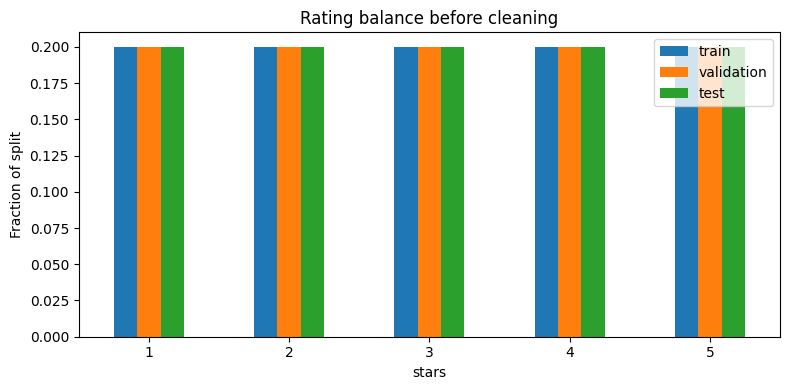

In [14]:
for name, split in raw.items():
    ratings = pd.Series(split["stars"])
    assert ratings.isin(range(1, 6)).all(), f"Invalid or missing stars in {name}"

def enrich(row, index):
    text = f"{row['review_title'] or ''} {row['review_body'] or ''}"
    return {
        "example_id": index,
        "labels": int(row["stars"]) - 1,
        "text_key": " ".join(text.lower().split()),
    }

prepared = DatasetDict({
    name: split.map(enrich, with_indices=True)
    for name, split in raw.items()
})

quality = []
for name, split in prepared.items():
    frame = split.select_columns(["review_title", "review_body", "stars", "text_key"]).to_pandas()
    quality.append({
        "split": name,
        "rows": len(frame),
        "missing_titles": frame.review_title.isna().sum(),
        "missing_bodies": frame.review_body.isna().sum(),
        "empty_reviews": frame.text_key.eq("").sum(),
        "invalid_ratings": (~frame.stars.isin(range(1, 6))).sum(),
        "within_split_duplicate_rows": frame.text_key.duplicated().sum(),
    })
display(pd.DataFrame(quality).set_index("split"))

balance = pd.DataFrame({
    name: pd.Series(split["stars"]).value_counts().reindex(range(1, 6), fill_value=0)
    for name, split in raw.items()
})
balance.index.name = "stars"
display(balance)
balance.div(balance.sum()).plot.bar(figsize=(8, 4), ylabel="Fraction of split", rot=0)
plt.title("Rating balance before cleaning")
plt.tight_layout()
plt.show()


### Missing text, encoding damage, and duplicate-label conflicts

A missing title is safe to replace with an empty string when a body exists. U+FFFD is a replacement character: the lost original character cannot reliably be recovered. Count and inspect it, but do not guess replacements or drop affected reviews. Duplicate groups with different star labels are ambiguous; retain them under the current study policy and report them separately.

In [15]:
audit_frame = prepared["train"].to_pandas()
text_columns = ["review_title", "review_body"]
text = audit_frame[text_columns].fillna("")
display(pd.DataFrame({
    "missing": audit_frame[text_columns].isna().sum(),
    "blank_after_fill": text.apply(lambda col: col.str.strip().eq("").sum()),
    "replacement_character": text.apply(lambda col: col.str.contains("\ufffd", regex=False).sum()),
}))
damaged = text.apply(lambda col: col.str.contains("\ufffd", regex=False)).any(axis=1)
display(audit_frame.loc[damaged, ["example_id", "stars", *text_columns]].head(5))

duplicate_groups = audit_frame.groupby("text_key").agg(
    rows=("stars", "size"), distinct_ratings=("stars", "nunique")
)
duplicate_groups = duplicate_groups[duplicate_groups.rows > 1]
display(pd.Series({
    "duplicate_groups": len(duplicate_groups),
    "extra_duplicate_rows": int((duplicate_groups.rows - 1).sum()),
    "conflicting_label_groups": int((duplicate_groups.distinct_ratings > 1).sum()),
}))
conflict_keys = duplicate_groups.index[duplicate_groups.distinct_ratings > 1]
display(audit_frame.loc[audit_frame.text_key.isin(conflict_keys),
                       ["example_id", "stars", "review_title", "review_body"]].head(10))


,missing,blank_after_fill,replacement_character
review_title,33,33,0
review_body,0,0,1


,example_id,stars,review_title,review_body
42639,42639,2,Help,3 months of decent few uses and now I�t consta...


duplicate_groups             97
extra_duplicate_rows        133
conflicting_label_groups      5
dtype: int64

,example_id,stars,review_title,review_body
57682,57682,2,Small,Smaller than anticipated
105320,105320,3,Small,It was smaller than expected
106193,106193,3,Small,Smaller than anticipated
116435,116435,3,I would buy it again.,I would buy it again.
136008,136008,4,Small,It was smaller than expected
138473,138473,4,Exactly as advertised,Exactly as advertised
149190,149190,4,Exactly as advertised,Exactly as advertised
152680,152680,4,I would buy it again.,I would buy it again.
156825,156825,4,good quality product,good quality product
161476,161476,5,Good quality product,Good quality product


## 3. Explore training review lengths and categories

count    200000.000000
mean         38.639755
std          35.216051
min           3.000000
50%          29.000000
90%          78.000000
95%         103.000000
99%         172.000000
max         772.000000
Name: word_count, dtype: float64

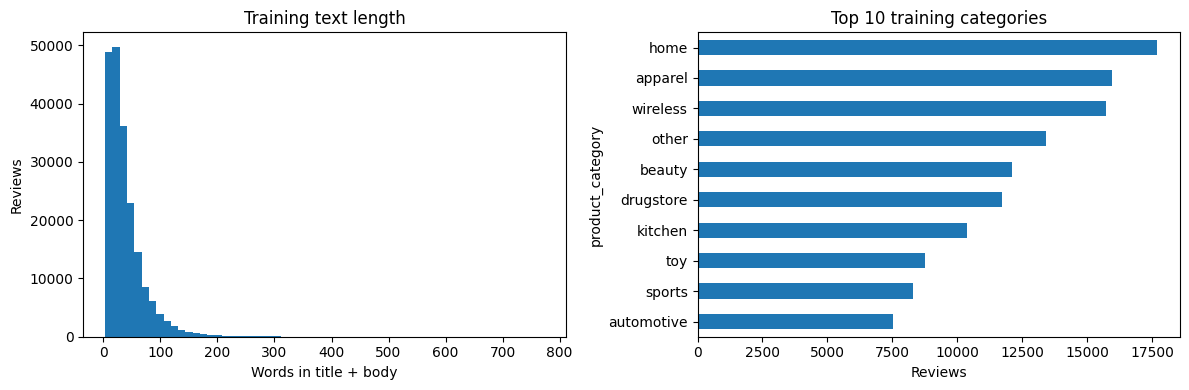

In [16]:
train_frame = raw["train"].to_pandas()
train_frame["word_count"] = (
    train_frame.review_title.fillna("") + " " + train_frame.review_body.fillna("")
).str.split().str.len()
display(train_frame.word_count.describe(percentiles=[0.5, 0.9, 0.95, 0.99]))
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
train_frame.word_count.plot.hist(bins=60, ax=axes[0])
axes[0].set(xlabel="Words in title + body", ylabel="Reviews", title="Training text length")
train_frame.product_category.value_counts().head(10).sort_values().plot.barh(ax=axes[1])
axes[1].set(xlabel="Reviews", title="Top 10 training categories")
fig.tight_layout()
plt.show()


## 4. Remove cross-split duplicates

Match `train.py`: preserve test copies, remove matching training and validation rows, and preserve validation over training. Within-split duplicates are reported above but retained. Original example IDs remain stable after filtering.

In [17]:
keys = {name: set(split["text_key"]) for name, split in prepared.items()}
pairs = [("train", "validation"), ("train", "test"), ("validation", "test")]
display(pd.DataFrame([
    {"split_a": a, "split_b": b, "shared_unique_texts": len(keys[a] & keys[b])}
    for a, b in pairs
]))

held_out_keys = keys["validation"] | keys["test"]
cleaned = DatasetDict({
    "train": prepared["train"].filter(lambda row: row["text_key"] not in held_out_keys),
    "validation": prepared["validation"].filter(lambda row: row["text_key"] not in keys["test"]),
    "test": prepared["test"],
})
cleaning_summary = pd.DataFrame([
    {"split": name, "before": len(prepared[name]), "after": len(split),
     "removed": len(prepared[name]) - len(split)}
    for name, split in cleaned.items()
]).set_index("split")
display(cleaning_summary)
clean_keys = {name: set(split["text_key"]) for name, split in cleaned.items()}
assert all(not (clean_keys[a] & clean_keys[b]) for a, b in pairs)


,split_a,split_b,shared_unique_texts
0,train,validation,7
1,train,test,4
2,validation,test,0


,before,after,removed
split,,,
train,200000,199984,16
validation,5000,5000,0
test,5000,5000,0


### Verify preparation preserves the task

The overlap table counts unique texts; the removal table counts rows, so 11 shared text keys can account for 16 removed rows. Check balance again after filtering. Do not rebalance a nearly balanced dataset automatically. Validate raw ratings before integer conversion and keep within-split repeats under the training script's existing policy.

In [18]:
after_balance = pd.DataFrame({
    name: pd.Series(split["stars"]).value_counts().reindex(range(1, 6), fill_value=0)
    for name, split in cleaned.items()
})
display(pd.DataFrame({
    "train_before": balance["train"],
    "train_after": after_balance["train"],
    "removed": balance["train"] - after_balance["train"],
    "after_percent": 100 * after_balance["train"] / after_balance["train"].sum(),
}))
display(pd.Series({
    "remaining_train_duplicate_rows": pd.Series(cleaned["train"]["text_key"]).duplicated().sum(),
    "held_out_overlap_rows_removed": int(cleaning_summary.loc["train", "removed"]),
}))


,train_before,train_after,removed,after_percent
1,40000,39993,7,19.9981
2,40000,40000,0,20.0016
3,40000,39997,3,20.0001
4,40000,39997,3,20.0001
5,40000,39997,3,20.0001


remaining_train_duplicate_rows    128
held_out_overlap_rows_removed      16
dtype: int64

## 5. Tokenize and apply truncation

The title and body are a **pair of sequences**, exactly as in training. The 128-token limit includes special tokens. `truncation=True` uses the tokenizer's longest-first strategy for pairs. We also measure untruncated lengths for this notebook's audit; these long sequences are never passed to a model. Padding is deferred until batching.

,reviews,median_tokens_before,p95_tokens_before,truncated_reviews,truncated_percent,mean_tokens_removed
split,,,,,,
train,199984,38.0,126.00,9497,4.74888,2.640921
validation,5000,38.0,128.00,247,4.94000,2.829600
test,5000,38.0,124.05,230,4.60000,2.302200


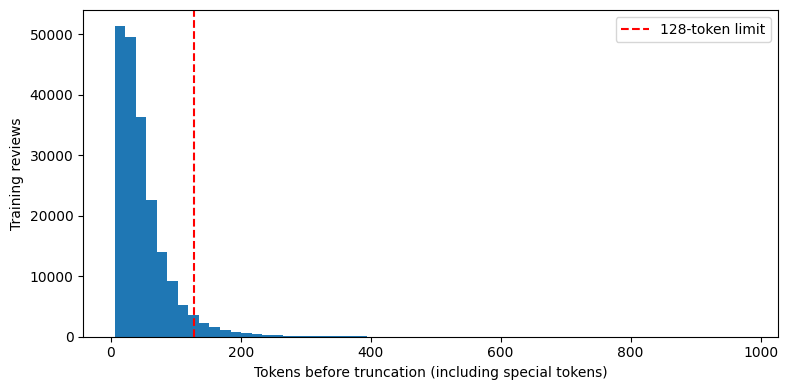

In [19]:
tokenizer = AutoTokenizer.from_pretrained(MODEL, clean_up_tokenization_spaces=False)

def tokenize(batch):
    titles = [value or "" for value in batch["review_title"]]
    bodies = [value or "" for value in batch["review_body"]]
    full_lengths = tokenizer(
        titles, bodies, truncation=False, return_length=True, verbose=False
    )["length"]
    encoded = tokenizer(titles, bodies, truncation=True, max_length=MAX_LENGTH)
    encoded.update(
        labels=batch["labels"],
        example_id=batch["example_id"],
        full_length=full_lengths,
    )
    return encoded

tokens = DatasetDict({
    name: split.map(tokenize, batched=True, remove_columns=split.column_names)
    for name, split in cleaned.items()
})

truncation_rows = []
for name, split in tokens.items():
    full = np.asarray(split["full_length"])
    kept = np.asarray([len(ids) for ids in split["input_ids"]])
    assert np.all(kept <= MAX_LENGTH)
    truncation_rows.append({
        "split": name,
        "reviews": len(split),
        "median_tokens_before": np.median(full),
        "p95_tokens_before": np.percentile(full, 95),
        "truncated_reviews": int((full > MAX_LENGTH).sum()),
        "truncated_percent": 100 * np.mean(full > MAX_LENGTH),
        "mean_tokens_removed": np.mean(full - kept),
    })
display(pd.DataFrame(truncation_rows).set_index("split"))

plt.figure(figsize=(8, 4))
plt.hist(tokens["train"]["full_length"], bins=60)
plt.axvline(MAX_LENGTH, color="red", linestyle="--", label=f"{MAX_LENGTH}-token limit")
plt.xlabel("Tokens before truncation (including special tokens)")
plt.ylabel("Training reviews")
plt.legend()
plt.tight_layout()
plt.show()


### Quantify the truncation trade-off using training data

Compare candidate limits descriptively; 128 remains the fixed study setting. The average token count is a length proxy, not a measured speed or memory benchmark. Report the loss among affected reviews as well as across all reviews, and check whether one rating class is disproportionately truncated.

,limit,truncated_percent,mean_tokens_kept,mean_tokens_removed_all,mean_tokens_removed_affected
0,64,23.634391,39.586392,10.062025,42.573659
1,128,4.748880,47.007496,2.640921,55.611456
2,192,1.349108,48.709387,0.939030,69.603781
3,256,0.473038,49.241504,0.406913,86.021142


,reviews,median_tokens,truncated_fraction,mean_tokens_removed
stars,,,,
1,39993,38.0,0.039157,1.968094
2,40000,42.0,0.057975,3.105825
3,39997,41.0,0.054879,3.204690
4,39997,39.0,0.056429,3.413756
5,39997,32.0,0.029002,1.512138


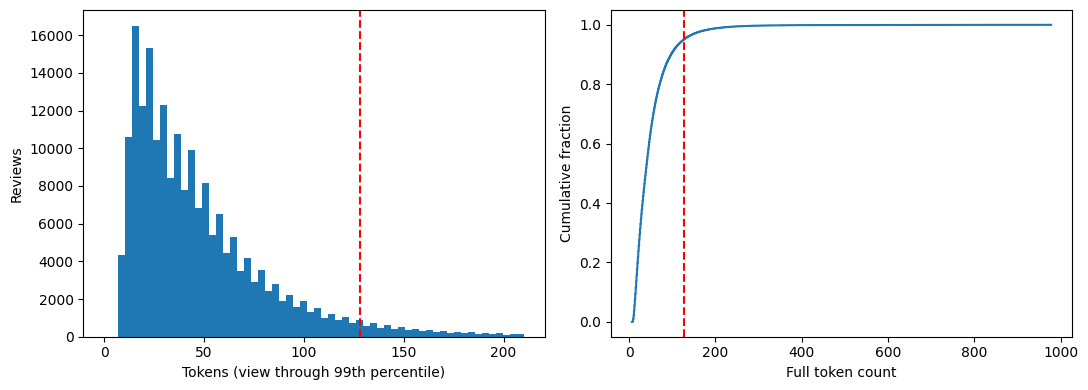

In [20]:
lengths = np.asarray(tokens["train"]["full_length"])
limit_comparison = pd.DataFrame([
    {"limit": limit,
     "truncated_percent": 100 * np.mean(lengths > limit),
     "mean_tokens_kept": np.minimum(lengths, limit).mean(),
     "mean_tokens_removed_all": np.maximum(lengths - limit, 0).mean(),
     "mean_tokens_removed_affected": (
         (lengths[lengths > limit] - limit).mean() if (lengths > limit).any() else 0)}
    for limit in (64, 128, 192, 256)
])
display(limit_comparison)
length_audit = pd.DataFrame({
    "stars": np.asarray(tokens["train"]["labels"]) + 1,
    "full_tokens": lengths,
    "truncated": lengths > MAX_LENGTH,
    "tokens_removed": np.maximum(lengths - MAX_LENGTH, 0),
})
display(length_audit.groupby("stars").agg(
    reviews=("stars", "size"),
    median_tokens=("full_tokens", "median"),
    truncated_fraction=("truncated", "mean"),
    mean_tokens_removed=("tokens_removed", "mean"),
))
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].hist(lengths, bins=60, range=(0, np.percentile(lengths, 99)))
axes[0].axvline(MAX_LENGTH, color="red", linestyle="--")
axes[0].set(xlabel="Tokens (view through 99th percentile)", ylabel="Reviews")
sorted_lengths = np.sort(lengths)
axes[1].plot(sorted_lengths, np.arange(1, len(lengths) + 1) / len(lengths))
axes[1].axvline(MAX_LENGTH, color="red", linestyle="--")
axes[1].set(xlabel="Full token count", ylabel="Cumulative fraction")
fig.tight_layout()
plt.show()


## 6. Inspect a truncated training example

Decoded text shows tokenization and truncation, so its spacing may differ from the original review.

In [21]:
long_positions = np.flatnonzero(np.asarray(tokens["train"]["full_length"]) > MAX_LENGTH)
if len(long_positions):
    position = int(long_positions[0])
    review = cleaned["train"][position]
    encoded = tokens["train"][position]
    display(pd.DataFrame([{
        "example_id": review["example_id"],
        "stars": review["stars"],
        "tokens_before": encoded["full_length"],
        "tokens_after": len(encoded["input_ids"]),
    }]))
    print("TITLE:", review["review_title"])
    print("\nBODY:", review["review_body"])
    print("\nTRUNCATED MODEL INPUT:", tokenizer.decode(encoded["input_ids"]))
else:
    print("No training reviews exceed the selected token limit.")


,example_id,stars,tokens_before,tokens_after
0,0,1,166,128


TITLE: I'll spend twice the amount of time boxing up the whole useless thing and send it back with a 1-star review ...

BODY: Arrived broken. Manufacturer defect. Two of the legs of the base were not completely formed, so there was no way to insert the casters. I unpackaged the entire chair and hardware before noticing this. So, I'll spend twice the amount of time boxing up the whole useless thing and send it back with a 1-star review of part of a chair I never got to sit in. I will go so far as to include a picture of what their injection molding and quality assurance process missed though. I will be hesitant to buy again. It makes me wonder if there aren't missing structures and supports that don't impede the assembly process.

TRUNCATED MODEL INPUT: [CLS] i ' ll spend twice the amount of time boxing up the whole useless thing and send it back with a 1 - star review... [SEP] arrived broken. manufacturer defect. two of the legs of the base were not completely formed, so there was no w

## 7. Check a padded batch

Remove notebook-only length metadata before batching. IDs are useful for tracking predictions but must also be removed before calling the model.

In [22]:
model_data = DatasetDict({
    name: split.remove_columns("full_length") for name, split in tokens.items()
})
collator = DataCollatorWithPadding(tokenizer, pad_to_multiple_of=8)
batch = collator([model_data["train"][i] for i in range(4)])
example_ids = batch.pop("example_id")
display({name: tuple(value.shape) for name, value in batch.items()})


{'labels': (4,), 'input_ids': (4, 128), 'attention_mask': (4, 128)}